In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

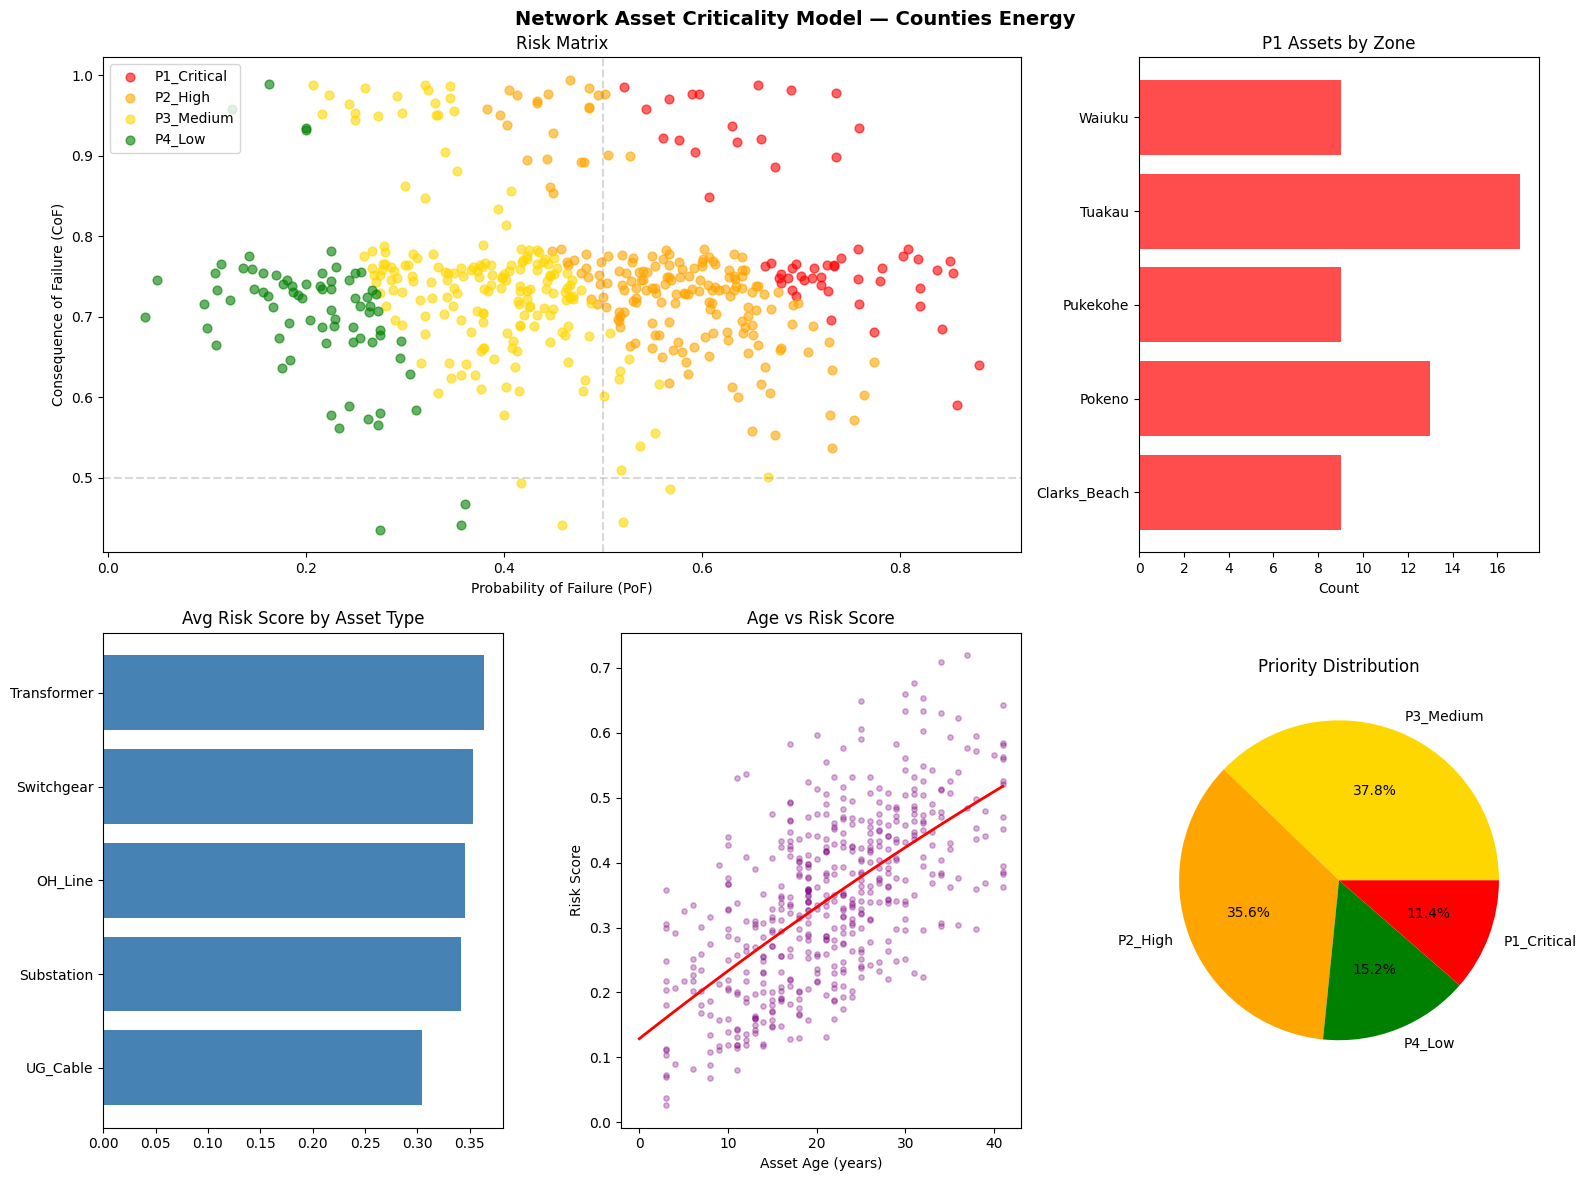

In [2]:
df = pd.read_csv('../data/processed/asset_scores.csv')

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Network Asset Criticality Model — Counties Energy',
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig)

COLORS = {'P1_Critical': 'red', 'P2_High': 'orange',
          'P3_Medium': 'gold', 'P4_Low': 'green'}

# 图1：风险矩阵
ax1 = fig.add_subplot(gs[0, :2])
for tier, grp in df.groupby('priority'):
    ax1.scatter(grp['pof_score'], grp['cof_score'],
                c=COLORS[tier], label=tier, alpha=0.6, s=40)
ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.3)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.3)
ax1.set_xlabel('Probability of Failure (PoF)')
ax1.set_ylabel('Consequence of Failure (CoF)')
ax1.set_title('Risk Matrix')
ax1.legend(loc='upper left')

# 图2：各区域P1数量
ax2 = fig.add_subplot(gs[0, 2])
zone_p1 = df[df['priority'] == 'P1_Critical'].groupby('zone').size()
ax2.barh(zone_p1.index, zone_p1.values, color='red', alpha=0.7)
ax2.set_title('P1 Assets by Zone')
ax2.set_xlabel('Count')

# 图3：各类型平均风险
ax3 = fig.add_subplot(gs[1, 0])
type_risk = df.groupby('asset_type')['risk_score'].mean().sort_values()
ax3.barh(type_risk.index, type_risk.values, color='steelblue')
ax3.set_title('Avg Risk Score by Asset Type')

# 图4：年龄 vs 风险趋势
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(df['age_years'], df['risk_score'], alpha=0.3, s=15, c='purple')
z = np.polyfit(df['age_years'], df['risk_score'], 2)
x_line = np.linspace(0, df['age_years'].max(), 100)
ax4.plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2)
ax4.set_xlabel('Asset Age (years)')
ax4.set_ylabel('Risk Score')
ax4.set_title('Age vs Risk Score')

# 图5：优先级饼图
ax5 = fig.add_subplot(gs[1, 2])
tier_counts = df['priority'].value_counts()
ax5.pie(tier_counts.values,
        labels=tier_counts.index,
        colors=[COLORS[t] for t in tier_counts.index],
        autopct='%1.1f%%')
ax5.set_title('Priority Distribution')

plt.tight_layout()
plt.savefig('../output/criticality_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
# Main PowerBI file
df.to_csv('../output/powerbi_main.csv', index=False)

# Zone-level summary for PowerBI
df.groupby('zone').agg(
    total_assets  = ('asset_id', 'count'),
    avg_risk      = ('risk_score', 'mean'),
    p1_count      = ('priority', lambda x: (x == 'P1_Critical').sum()),
    total_cost    = ('cost_nzd', 'sum'),
).reset_index().to_csv('../output/powerbi_zone.csv', index=False)

# Top 50 Investment Recommendations
df[df['priority'].isin(['P1_Critical', 'P2_High'])]\
  .sort_values('risk_score', ascending=False)\
  .head(50)\
  .to_csv('../output/powerbi_investment.csv', index=False)

print("PowerBI files have been output to output/")

PowerBI files have been output to output/
